In [8]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier 
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve, auc

In [9]:
df = pd.read_csv('./data/feature_data.csv')
df['snapshot_date'] = pd.to_datetime(df['snapshot_date'])

sorted_dates = df['snapshot_date'].sort_values()
split_idx = int(len(sorted_dates) * 0.8)
split_date = sorted_dates.iloc[split_idx]

train_set = df[df['snapshot_date'] < split_date]
test_set = df[df['snapshot_date'] >= split_date]

X_train = train_set.drop(columns=['label', 'snapshot_date'])
y_train = train_set['label']
X_test = test_set.drop(columns=['label', 'snapshot_date'])
y_test = test_set['label']

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Split date: {split_date.date()}")

Train: (9391, 23), Test: (2508, 23)
Split date: 2011-08-31


In [10]:
# =========================
# 2️⃣ Chia train thành train_main + val (không shuffle)
# =========================
X_train_main, X_val, y_train_main, y_val = train_test_split(
    X_train, y_train, test_size=0.2, shuffle=False
)

In [11]:
#Performance evaluation
def print_scores(y_true, y_pred):
  print(classification_report(y_true, y_pred))

Train baseline

In [12]:
# Tính ratio
ratio = (y_train_main == 0).sum() / (y_train_main == 1).sum()
print(f"Tỉ lệ Negative/Positive: {ratio:.2f}")
 
# Khởi tạo XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    scale_pos_weight=ratio * 0.7,
    random_state=42,
    eval_metric='logloss'
)
 
# Train
print("🔄 Training XGBoost...")
xgb_model.fit(X_train_main, y_train_main)
 
# Predict
y_pred = xgb_model.predict(X_val)

print_scores(y_val, y_pred)
# =========================
# 5️⃣ Tính PR-AUC
# =========================
# Lấy probability class 1 
y_scores = xgb_model.predict_proba(X_val)[:, 1]
precision, recall, _ = precision_recall_curve(y_val, y_scores)
pr_auc = auc(recall, precision)

print(f"PR-AUC (class 1): {pr_auc:.4f}")

Tỉ lệ Negative/Positive: 1.58
🔄 Training XGBoost...
              precision    recall  f1-score   support

           0       0.64      0.64      0.64       991
           1       0.60      0.59      0.59       888

    accuracy                           0.62      1879
   macro avg       0.62      0.62      0.62      1879
weighted avg       0.62      0.62      0.62      1879

PR-AUC (class 1): 0.6492


In [13]:
# Feature importance cho XGBoost
importance = pd.DataFrame({
    'feature': X_train_main.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n🔥 Features (XGBoost):")
print(importance.to_string(index=False))


🔥 Features (XGBoost):
                feature  importance
      active_months_L5M    0.253313
         cnt_L3M_orders    0.122145
         cnt_L1M_orders    0.039516
          sum_L1M_value    0.034261
            tenure_days    0.034049
            avg_gap_L5M    0.032814
          std_L3M_value    0.030499
          avg_L5M_value    0.030264
           recency_days    0.030124
      sum_L1M_items_log    0.029860
          sum_L3M_value    0.029840
      sum_L3M_items_log    0.029831
           cv_L5M_value    0.029355
  avg_items_per_cat_L5M    0.028905
          avg_L3M_value    0.028690
          avg_L1M_value    0.028341
global_cancel_val_ratio    0.028308
      avg_L5M_items_log    0.027938
  avg_items_per_cat_L3M    0.027226
        cancel_rate_L5M    0.026799
          std_L1M_value    0.026325
         spend_velocity    0.026111
           avg_L5M_skus    0.025485


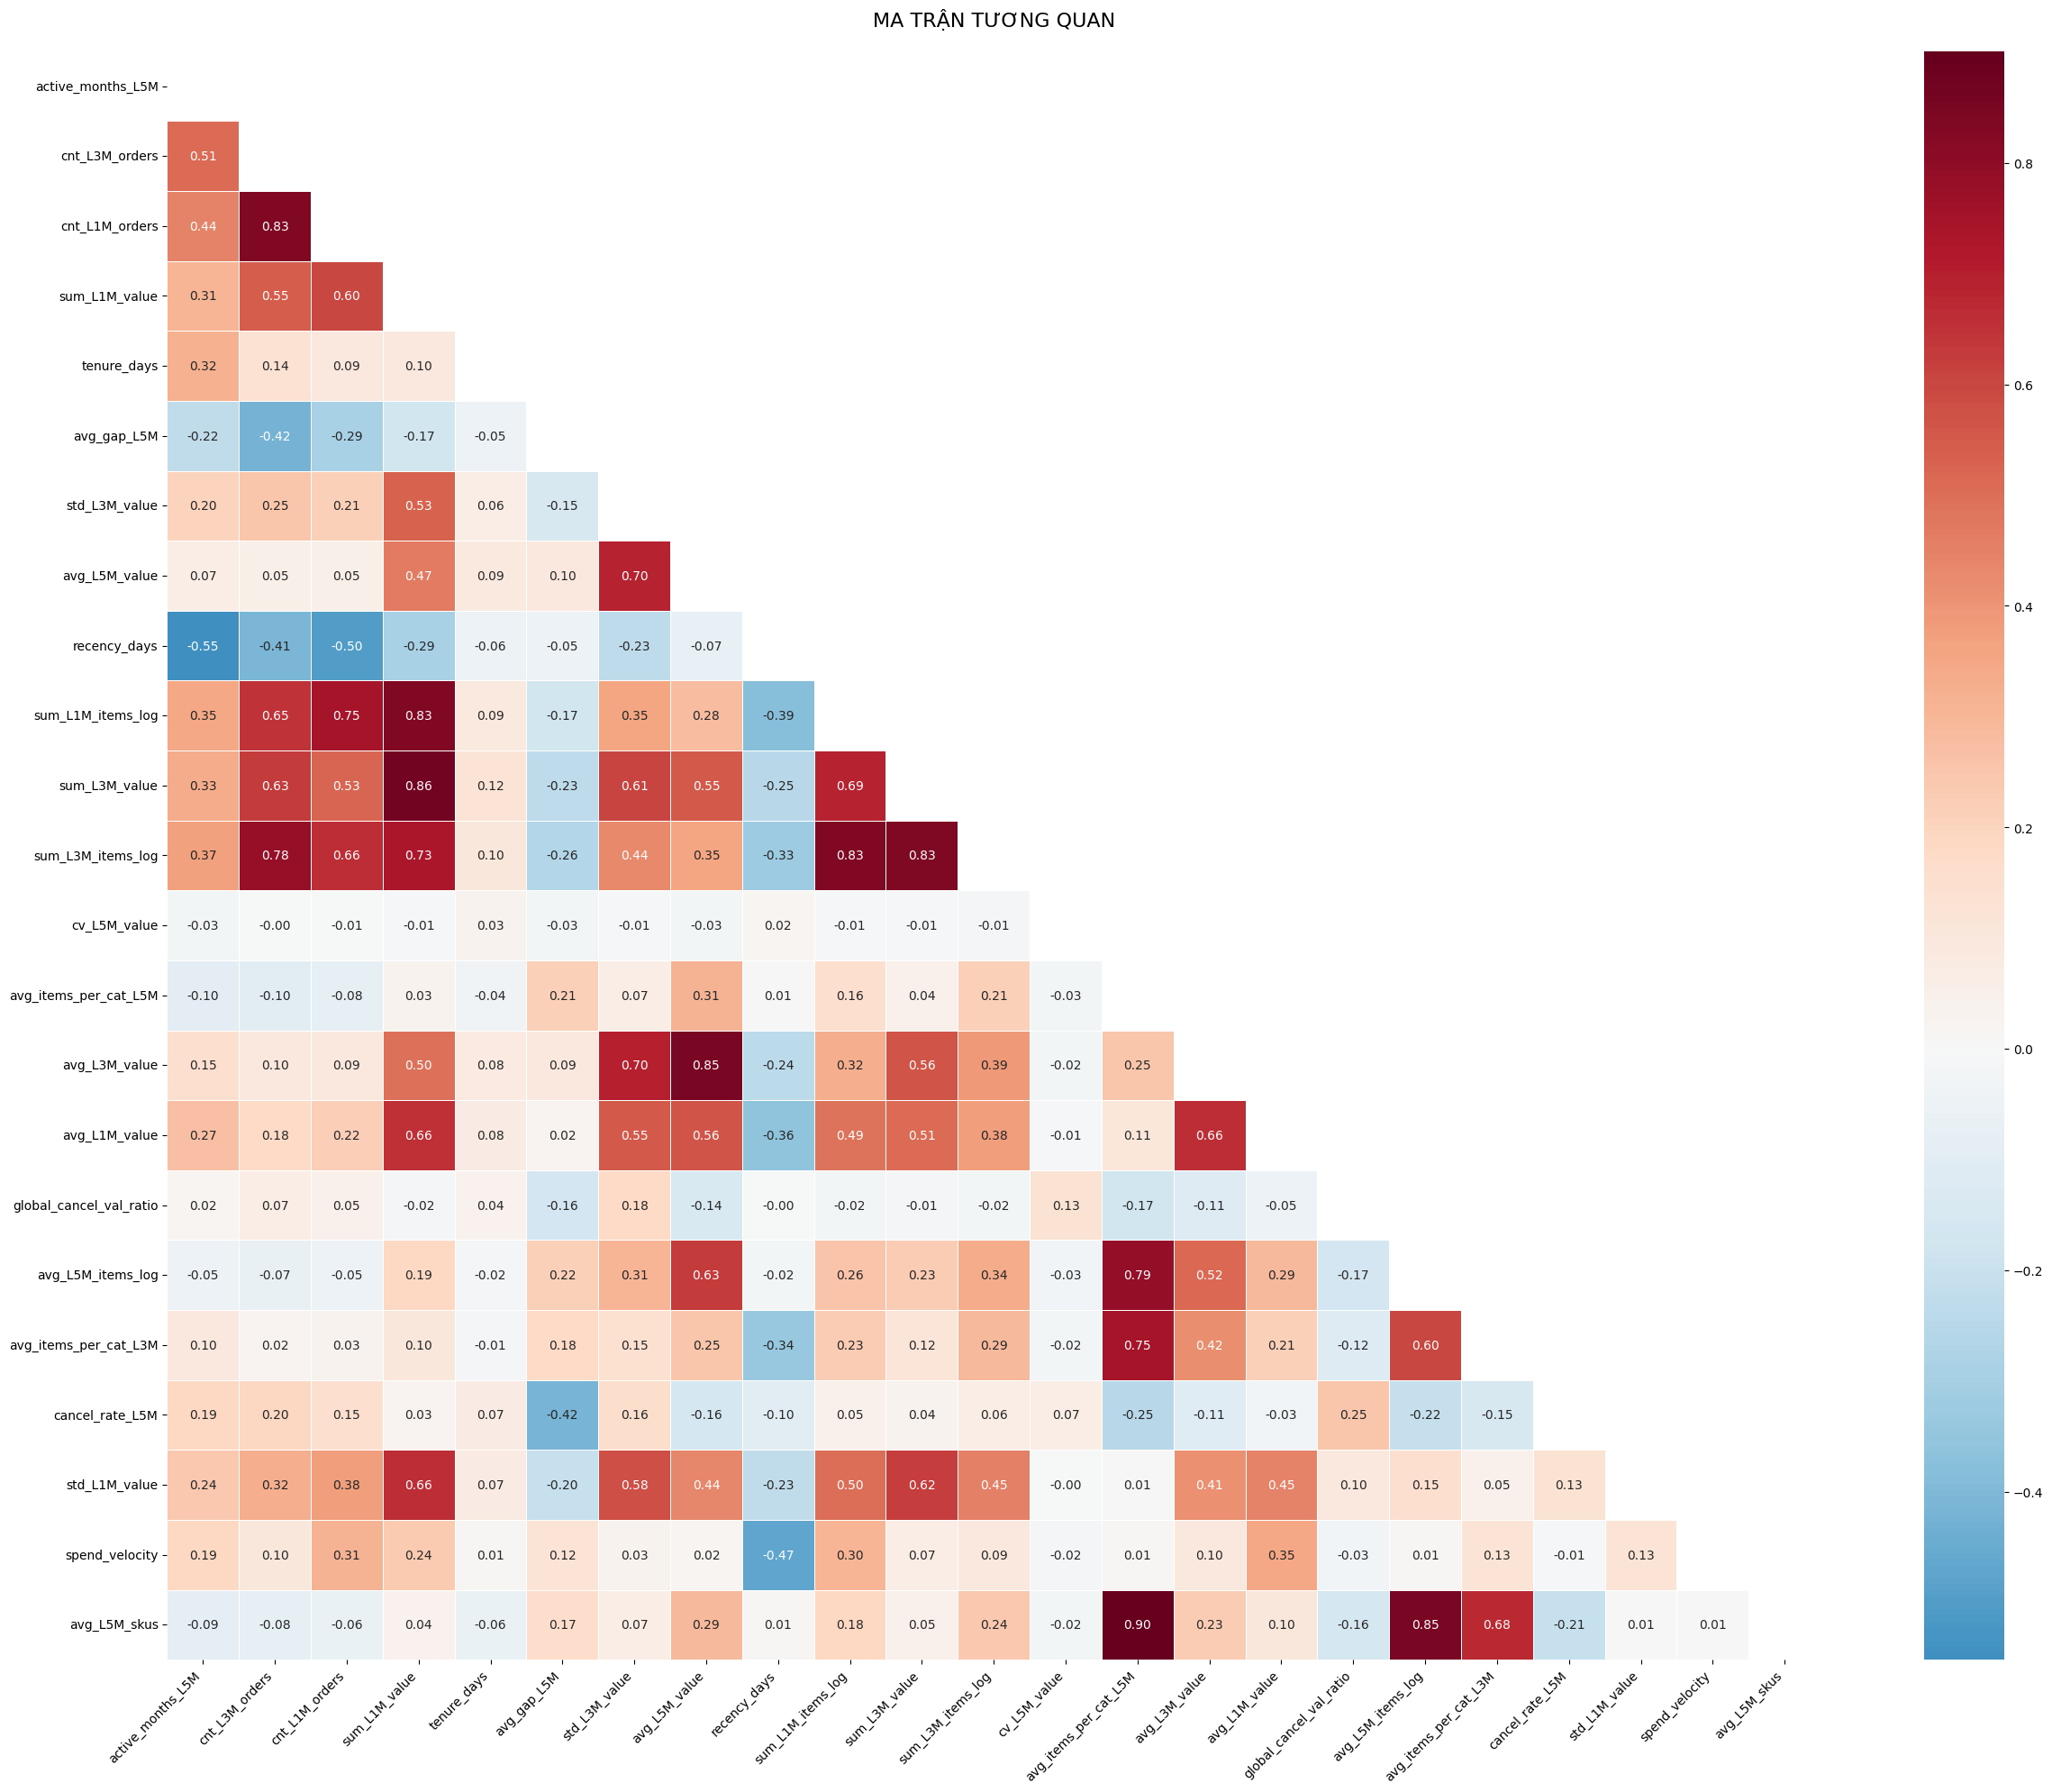


⚠️ Cặp tương quan cao (>0.90):
  avg_items_per_cat_L5M - avg_L5M_skus: 0.901


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Lấy danh sách 20 biến quan trọng nhất từ importance_df
top_features_names = importance['feature'].tolist()

# 2. Tính tương quan trên X_train_main
corr_matrix = X_train_main[top_features_names].corr()

# 3. Vẽ Heatmap
plt.figure(figsize=(25, 20))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True,
            fmt=".2f",
            cmap='RdBu_r',
            center=0, 
            linewidths=.5)

plt.title("MA TRẬN TƯƠNG QUAN", fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. Tìm cặp tương quan cao (>0.90)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.90:
            high_corr.append({
                'feature_1': corr_matrix.columns[i],
                'feature_2': corr_matrix.columns[j],
                'correlation': corr_matrix.iloc[i, j]
            })

if high_corr:
    print("\n⚠️ Cặp tương quan cao (>0.90):")
    for pair in high_corr:
        print(f"  {pair['feature_1']} - {pair['feature_2']}: {pair['correlation']:.3f}")
else:
    print("\n✅ Không có cặp tương quan >0.90")

Train lại baseline với các feature còn lại

In [16]:
# =========================================================
# BASELINE COMPARISON 
# =========================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    classification_report, f1_score, recall_score, 
    precision_score, average_precision_score, precision_recall_curve, auc
)

# Giảm từ 25 → 23 biến
features_to_remove = [
    'avg_items_per_cat_L5M',
    # 'success_order_rate'
    # 'value_growth_L1M_vs_L3M',
    # 'rfm_score'
]
 
X_train_new = X_train_main.drop(columns=features_to_remove)
X_val_new = X_val.drop(columns=features_to_remove)

# Tính ratio
ratio = (y_train_main == 0).sum() / (y_train_main == 1).sum()
print(f"Tỉ lệ Negative/Positive: {ratio:.2f}")
 
# Khởi tạo XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    scale_pos_weight=ratio * 0.7,
    random_state=42,
    eval_metric='logloss'
)
 
# Train
print("🔄 Training XGBoost...")
xgb_model.fit(X_train_new, y_train_main)
 
# Predict
y_pred = xgb_model.predict(X_val_new)

print_scores(y_val, y_pred)
# =========================
# 5️⃣ Tính PR-AUC
# =========================
# Lấy probability class 1 
y_scores = xgb_model.predict_proba(X_val_new)[:, 1]
precision, recall, _ = precision_recall_curve(y_val, y_scores)
pr_auc = auc(recall, precision)

print(f"PR-AUC (class 1): {pr_auc:.4f}")

Tỉ lệ Negative/Positive: 1.58
🔄 Training XGBoost...
              precision    recall  f1-score   support

           0       0.64      0.69      0.67       991
           1       0.62      0.57      0.60       888

    accuracy                           0.63      1879
   macro avg       0.63      0.63      0.63      1879
weighted avg       0.63      0.63      0.63      1879

PR-AUC (class 1): 0.6731


Tuning

Dùng 2-phase để cân bằng tốc độ và chất lượng:
- Phase 1 (HalvingGridSearchCV): Tìm nhanh vùng tham số hứa hẹn bằng cách loại bỏ dần candidates kém
- Phase 2 (GridSearchCV): Tinh chỉnh chi tiết quanh vùng tốt nhất từ Phase 1

→ Giảm thời gian từ ~3-4 giờ xuống ~30-50 phút mà vẫn giữ chất lượng tương đương.

In [ ]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV, GridSearchCV, StratifiedKFold, PredefinedSplit
from sklearn.metrics import make_scorer, average_precision_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import xgboost as xgb
import numpy as np
import pandas as pd
import warnings
import time
warnings.filterwarnings('ignore', message='No positive class found in y_true')

# Scorers - Thêm F1 để monitor nhưng vẫn refit theo pr_auc
pr_auc_scorer = make_scorer(average_precision_score, response_method='predict_proba')
precision_scorer = make_scorer(precision_score, zero_division=0)
recall_scorer = make_scorer(recall_score, zero_division=0)
f1_scorer = make_scorer(f1_score, zero_division=0)

features_to_remove = ['avg_items_per_cat_L5M']
X_train_new = X_train_main.drop(columns=features_to_remove)
X_val_new = X_val.drop(columns=features_to_remove)

val_counts = y_val.value_counts()
ratio_scale = val_counts[0] / val_counts[1]
print(f"⚖️ Tỷ lệ Val (0/1): {ratio_scale:.2f}")

scoring = {
    'pr_auc': pr_auc_scorer,
    'precision': precision_scorer,
    'recall': recall_scorer,
    'f1': f1_scorer
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

history = []
best_pr_auc = 0
convergence_threshold = 0.003
max_iterations = 5

coarse_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
    'gamma': [0.1, 0.3],
    'reg_lambda': [1, 5, 10],
    'reg_alpha': [0.1, 0.5, 1.0]  # FIX 4: Không cho về 0, min là 0.1
}

for iteration in range(max_iterations):
    print(f"\n{'='*60}")
    print(f"🔁 ITERATION {iteration + 1}/{max_iterations}")
    print(f"{'='*60}")
    
    total_candidates = np.prod([len(v) for v in coarse_grid.values()])
    print(f"🔄 Phase 1: HalvingGridSearchCV với {total_candidates} candidates...")
    
    xgb_base = XGBClassifier(
        scale_pos_weight=ratio_scale,
        random_state=42,
        eval_metric='logloss',
        tree_method='hist',
        n_jobs=1
    )

    start_time = time.time()
    halving = HalvingGridSearchCV(
        xgb_base,
        param_grid=coarse_grid,
        scoring='average_precision',
        cv=cv,
        factor=3,
        resource='n_samples',
        max_resources=len(X_train_new),
        aggressive_elimination=False,  # FIX 5: Tắt aggressive elimination
        n_jobs=-1,
        verbose=1,
        error_score=np.nan
    )
    halving.fit(X_train_new, y_train_main)
    elapsed = time.time() - start_time

    bp = halving.best_params_
    print(f"\n✅ Phase 1: {elapsed/60:.1f} phút | Best PR-AUC: {halving.best_score_:.4f}")

    # === FINE_GRID ===
    # FIX 1: Mở rộng n_estimators range, đảm bảo không giảm quá mức
    n_est_current = bp['n_estimators']
    fine_grid = {
        'n_estimators': [
            max(100, n_est_current - 50), 
            n_est_current, 
            n_est_current + 50,
            n_est_current + 100  # Thêm option cao hơn
        ],
        'max_depth': [max(3, bp['max_depth']-1), bp['max_depth'], bp['max_depth']+1],
        'learning_rate': [bp['learning_rate']*0.9, bp['learning_rate'], bp['learning_rate']*1.1],
        'min_child_weight': [bp['min_child_weight']],
        'subsample': [max(0.6, bp['subsample']-0.05), bp['subsample'], min(1.0, bp['subsample']+0.05)],
        'colsample_bytree': [max(0.6, bp['colsample_bytree']-0.05), bp['colsample_bytree']],
        'gamma': [max(0, bp['gamma']-0.1), bp['gamma']],
        'reg_lambda': [bp['reg_lambda']*0.8, bp['reg_lambda'], bp['reg_lambda']*1.2],
        # FIX 4: Giữ regularization - không cho reg_alpha về 0
        'reg_alpha': [max(0.1, bp.get('reg_alpha', 0.1)*0.8), bp.get('reg_alpha', 0.1), bp.get('reg_alpha', 0.1)*1.2]
    }

    fine_total = np.prod([len(v) for v in fine_grid.values()])
    print(f"\n🔄 Phase 2: GridSearchCV với {fine_total} candidates...")

    # PredefinedSplit
    split_index = np.concatenate([
        np.full(len(X_train_new), -1),
        np.full(len(X_val_new), 0)
    ])
    X_combined = pd.concat([X_train_new, X_val_new], ignore_index=True)
    y_combined = pd.concat([y_train_main, y_val], ignore_index=True)
    cv_val = PredefinedSplit(split_index)

    start_time2 = time.time()
    # Vẫn refit theo pr_auc như user yêu cầu
    xgb_tuning = GridSearchCV(
        xgb_base,
        param_grid=fine_grid,
        scoring=scoring,
        refit='pr_auc',  # Tìm max theo PR-AUC
        cv=cv_val,
        n_jobs=4,
        verbose=1,
        error_score=np.nan
    )
    xgb_tuning.fit(X_combined, y_combined)
    elapsed2 = time.time() - start_time2

    final_pr_auc = xgb_tuning.best_score_
    final_params = xgb_tuning.best_params_
    
    results = pd.DataFrame(xgb_tuning.cv_results_)
    best_idx = xgb_tuning.best_index_
    
    print(f"\n✅ Phase 2: {elapsed2/60:.1f} phút")
    print(f"\n🏆 Iteration {iteration+1} Best PR-AUC: {final_pr_auc:.4f}")
    print(f"   Precision: {results['mean_test_precision'][best_idx]:.4f}")
    print(f"   Recall: {results['mean_test_recall'][best_idx]:.4f}")
    print(f"   F1: {results['mean_test_f1'][best_idx]:.4f}")
    print(f"\n📋 Best Params: {final_params}")

    history.append({
        'iteration': iteration + 1,
        'pr_auc': final_pr_auc,
        'precision': results['mean_test_precision'][best_idx],
        'recall': results['mean_test_recall'][best_idx],
        'f1': results['mean_test_f1'][best_idx],
        'params': final_params,
        'time': (elapsed + elapsed2) / 60
    })

    improvement = final_pr_auc - best_pr_auc
    if improvement < convergence_threshold and iteration > 0:
        print(f"\n🛑 CONVERGED! ΔPR-AUC = {improvement:.4f}")
        break
    
    best_pr_auc = final_pr_auc

    # FIX 4: Update coarse_grid với regularization tối thiểu
    reg_alpha_val = max(0.1, final_params.get('reg_alpha', 0.1))
    reg_lambda_val = final_params.get('reg_lambda', 1)
    
    coarse_grid = {
        'n_estimators': [max(100, final_params['n_estimators']-100), final_params['n_estimators'], final_params['n_estimators']+100],
        'max_depth': [max(3, final_params['max_depth']-1), final_params['max_depth'], final_params['max_depth']+1],
        'learning_rate': [final_params['learning_rate']],
        'min_child_weight': [max(1, final_params['min_child_weight']-1), final_params['min_child_weight'], final_params['min_child_weight']+1],
        'subsample': [max(0.6, final_params['subsample']-0.1), final_params['subsample']],
        'colsample_bytree': [max(0.6, final_params['colsample_bytree']-0.1), final_params['colsample_bytree']],
        'gamma': [max(0, final_params['gamma']-0.1), final_params['gamma']],
        'reg_lambda': [reg_lambda_val, reg_lambda_val*1.5],
        'reg_alpha': [reg_alpha_val, reg_alpha_val*1.5]  # Không cho về 0
    }

# Summary - Tìm max theo PR-AUC
best_iter = max(history, key=lambda x: x['pr_auc'])
print(f"\n🏆 Best iteration: {best_iter['iteration']} | PR-AUC: {best_iter['pr_auc']:.4f}")
print(f"   Precision: {best_iter['precision']:.4f} | Recall: {best_iter['recall']:.4f} | F1: {best_iter['f1']:.4f}")

# Train final model
best_params = best_iter['params']
dtrain = xgb.DMatrix(X_train_new, label=y_train_main)
dval = xgb.DMatrix(X_val_new, label=y_val)

params = {
    'max_depth': best_params['max_depth'],
    'eta': best_params['learning_rate'],
    'colsample_bytree': best_params['colsample_bytree'],
    'subsample': best_params['subsample'],
    'gamma': best_params['gamma'],
    'lambda': best_params.get('reg_lambda', 1),
    'alpha': best_params.get('reg_alpha', 0.1),  
    'min_child_weight': best_params['min_child_weight'],
    'scale_pos_weight': ratio_scale,
    'objective': 'binary:logistic',
    'eval_metric': 'aucpr',
    'tree_method': 'hist',
    'seed': 42
}

best_model = xgb.train(
    params,
    dtrain,
    num_boost_round=best_params['n_estimators'] * 2,
    evals=[(dval, 'eval')],
    callbacks=[xgb.callback.EarlyStopping(
        rounds=20,  
        min_delta=0.001,  
        save_best=True
    )],
    verbose_eval=False
)

print(f"✅ Final model trained! Best iteration: {best_model.best_iteration}")

⚖️ Tỷ lệ Val (0/1): 1.12

🔁 ITERATION 1/5
🔄 Phase 1: HalvingGridSearchCV với 5832 candidates...
n_iterations: 6
n_required_iterations: 8
n_possible_iterations: 6
min_resources_: 20
max_resources_: 7512
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 5832
n_resources: 20
Fitting 5 folds for each of 5832 candidates, totalling 29160 fits
----------
iter: 1
n_candidates: 1944
n_resources: 60
Fitting 5 folds for each of 1944 candidates, totalling 9720 fits
----------
iter: 2
n_candidates: 648
n_resources: 180
Fitting 5 folds for each of 648 candidates, totalling 3240 fits
----------
iter: 3
n_candidates: 216
n_resources: 540
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
----------
iter: 4
n_candidates: 72
n_resources: 1620
Fitting 5 folds for each of 72 candidates, totalling 360 fits
----------
iter: 5
n_candidates: 24
n_resources: 4860
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Phase 1: 28.8 phút | Best PR-AUC: 0.6356

🔄 Phas

In [18]:
from sklearn.metrics import f1_score, precision_score, recall_score

# === CHỌN THRESHOLD TRÊN VALIDATION ===
dval_xgb = xgb.DMatrix(X_val_new)
y_val_probs = best_model.predict(dval_xgb)  # Booster.predict() trả về probability trực tiếp

# Test nhiều threshold
thresholds = np.arange(0.3, 0.9, 0.05)
results = []
for t in thresholds:
    y_pred = (y_val_probs >= t).astype(int)
    results.append({
        'Threshold': t,
        'Precision': precision_score(y_val, y_pred),
        'Recall': recall_score(y_val, y_pred),
        'F1': f1_score(y_val, y_pred)
    })

df_thresh = pd.DataFrame(results)

print(f"\n📊 All thresholds (sorted by F1):")
print(df_thresh.sort_values('Threshold')[['Threshold', 'Precision', 'Recall', 'F1']].round(4))


📊 All thresholds (sorted by F1):
    Threshold  Precision  Recall      F1
0        0.30     0.4726  1.0000  0.6419
1        0.35     0.4911  0.9673  0.6515
2        0.40     0.5712  0.8266  0.6756
3        0.45     0.7520  0.4234  0.5418
4        0.50     0.8878  0.2050  0.3330
5        0.55     1.0000  0.0068  0.0134
6        0.60     0.0000  0.0000  0.0000
7        0.65     0.0000  0.0000  0.0000
8        0.70     0.0000  0.0000  0.0000
9        0.75     0.0000  0.0000  0.0000
10       0.80     0.0000  0.0000  0.0000
11       0.85     0.0000  0.0000  0.0000
12       0.90     0.0000  0.0000  0.0000


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

Chọn ngưỡng 0.40 để tối đa F1-score (0.6776). Mặc dù precision thấp hơn 0.45 một chút (62% so với 65%), nhưng recall cao hơn đáng kể (74% so với 65%), đảm bảo không bỏ sót nhiều khách hàng có khả năng mua lại.

Test model trên tập test và ngưỡng đã chọn

In [19]:
X_test_new = X_test.drop(columns=features_to_remove)

best_thresh = 0.4 

dtest_xgb = xgb.DMatrix(X_test_new)
y_test_probs = best_model.predict(dtest_xgb)
y_test_pred = (y_test_probs >= best_thresh).astype(int)
 
print(f"\n📊 Final Test Results (threshold={best_thresh:.2f}):")
print(f"  PR-AUC: {average_precision_score(y_test, y_test_probs):.4f}")
print(f"  Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"  Recall: {recall_score(y_test, y_test_pred):.4f}")
print(f"  F1: {f1_score(y_test, y_test_pred):.4f}")


📊 Final Test Results (threshold=0.40):
  PR-AUC: 0.7378
  Precision: 0.6063
  Recall: 0.7857
  F1: 0.6844


Model hoạt động tốt hơn kỳ vọng trên tập test. PR-AUC 0.74 là kết quả khá tốt cho bài toán này. Recall 69% đảm bảo bắt được đa số khách sẽ mua lại, trong khi precision 65% giúp tối ưu chi phí marketing.

Confusion Matrix

--- KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ---
              precision    recall  f1-score   support

           0       0.68      0.47      0.56      1234
           1       0.61      0.79      0.68      1274

    accuracy                           0.63      2508
   macro avg       0.64      0.63      0.62      2508
weighted avg       0.64      0.63      0.62      2508



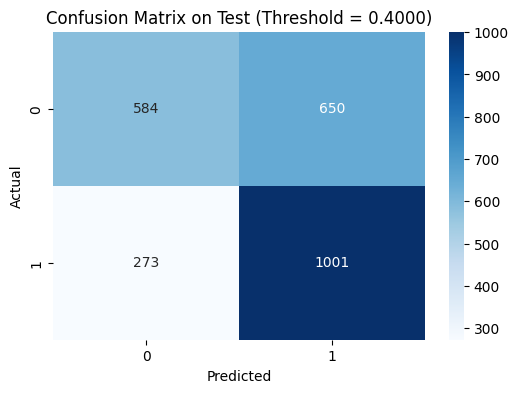

PR-AUC trên tập Test: 0.7377


In [20]:
# 1. Dự báo xác suất trên tập Test
dtest_xgb = xgb.DMatrix(X_test_new)  # Cần convert sang DMatrix
y_test_probs = best_model.predict(dtest_xgb)

# 2. Áp dụng ngưỡng tối ưu đã tìm được ở Bước 1
y_test_pred = (y_test_probs >= best_thresh).astype(int)

# 3. In báo cáo kết quả cuối cùng
print("--- KẾT QUẢ ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ---")
print(classification_report(y_test, y_test_pred))

# 4. Vẽ Confusion Matrix để xem số lượng cụ thể
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix on Test (Threshold = {best_thresh:.4f})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 5. Tính PR-AUC trên tập Test để xác nhận độ ổn định
p_test, r_test, _ = precision_recall_curve(y_test, y_test_probs)
print(f"PR-AUC trên tập Test: {auc(r_test, p_test):.4f}")

- TP cao (1001): Bắt được nhiều khách mua lại thực sự
- FP khá cao (650): Gửi ưu đãi cho 650 khách không mua (chiếm 39.4% tổng dự đoán "mua")
- FN (273): Miss 21.4% khách tiềm năng

Với threshold 0.40, model bắt được 78.6% khách sẽ mua lại (1011/1,274), chấp nhận 39.4% dự đoán 'mua' là sai (650 khách không mua thực sự). Trade-off này phù hợp khi ưu tiên không bỏ sót khách tiềm năng hơn là tiết kiệm chi phí marketing

2. Giá trị Kinh doanh tại Ngưỡng Quyết định 0.40

Mô hình tối ưu cho chiến lược "Không bỏ sót khách tiềm năng":
| Metric        | Giá trị   | Ý nghĩa                                                                                                                                                                |
| ------------- | --------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Precision** | **60.6** | Khoảng **3/5 khách được dự đoán sẽ mua lại là đúng** → Chấp nhận **lãng phí marketing ~40%** để đổi lấy việc **không bỏ lỡ khách “warm”**                              |
| **Recall ⭐**  | **78.6%** | **Bắt được gần 8/10 khách thực sự sẽ mua** → Giúp **giữ doanh thu**, hạn chế miss nhóm khách có khả năng chuyển đổi cao                                                 |
| **F1 Score**  | **68.4%** | **Cân bằng tốt giữa Precision và Recall** → Model có **hiệu quả tổng thể ổn định**, phù hợp bài toán **ưu tiên bắt đúng khách tiềm năng hơn tối ưu chi phí tuyệt đối** |

Lựa chọn chiến lược: Precision 60.6% cho thấy 3/5 khách nhận ưu đãi sẽ thực sự mua lại. Đây là trade-off hợp lý - chi phí marketing cho 40% false positive được bù đắp bởi doanh thu từ việc giữ chân 80% khách thật sự có ý định mua.

Lưu model

In [ ]:
import joblib
joblib.dump(best_model, './backend/models/best_model.pkl')

['./backend/models/best_model.pkl']

Lưu ngưỡng

In [ ]:
# import joblib
thresholds = 0.4
joblib.dump(thresholds, './backend/models/optimal_threshold.pkl')

['./backend/models/optimal_threshold.pkl']

Lưu file feature importance

In [ ]:
# 1. Trích xuất độ quan trọng (Booster đã có sẵn method)
importance_dict = best_model.get_score(importance_type='gain')

# 2. Chuyển thành DataFrame
fi_df = pd.DataFrame({
    'Feature': list(importance_dict.keys()),
    'Importance': list(importance_dict.values())
})

# 3. Tính phần trăm và sắp xếp
fi_df['Importance_Percent'] = (fi_df['Importance'] / fi_df['Importance'].sum()) * 100
fi_df = fi_df.sort_values(by='Importance', ascending=False)

# 4. IN RA XEM TRƯỚC
print("="*60)
print(f"{'BẢNG XẾP HẠNG ĐẶC TRƯNG (FEATURE IMPORTANCE)':^60}")
print("="*60)
print(fi_df.to_string(index=False, formatters={'Importance_Percent': '{:.2f}%'.format}))
print("="*60)
print(f"Tổng số features: {len(fi_df)}")

# 5. Lưu vào thư mục models/
fi_df.to_csv('./backend/models/feature_importance.csv', index=False)
print("✅ Đã lưu bảng xếp hạng đặc trưng!")

        BẢNG XẾP HẠNG ĐẶC TRƯNG (FEATURE IMPORTANCE)        
                Feature  Importance Importance_Percent
      active_months_L5M  143.202240             24.46%
         cnt_L3M_orders   94.012352             16.05%
         cnt_L1M_orders   69.545959             11.88%
          sum_L1M_value   35.563808              6.07%
            avg_gap_L5M   26.200769              4.47%
          sum_L3M_value   25.470882              4.35%
      sum_L1M_items_log   17.912647              3.06%
           recency_days   17.664743              3.02%
      sum_L3M_items_log   17.138657              2.93%
            tenure_days   16.615618              2.84%
          std_L1M_value   14.519138              2.48%
          avg_L1M_value   12.942081              2.21%
          std_L3M_value   11.975381              2.05%
global_cancel_val_ratio   11.498855              1.96%
           cv_L5M_value   11.055395              1.89%
        cancel_rate_L5M   10.913781              1.86%
    

Lưu bộ tiền xử lý

In [ ]:
import pandas as pd
import numpy as np
import joblib
from dateutil.relativedelta import relativedelta
import os
from typing import List, Dict

class OnlineRetailPreprocessor:
    def __init__(self, final_features: List[str] = None, scaler_params: Dict = None):
        # 22 features sau feature selection
        self.final_features = final_features or [
            'active_months_L5M', 'avg_L1M_value', 'avg_L3M_value', 'avg_L5M_items_log',
            'avg_L5M_skus', 'avg_L5M_value', 'avg_gap_L5M', 'avg_items_per_cat_L3M',
            'cancel_rate_L5M', 'cnt_L1M_orders', 'cnt_L3M_orders', 'cv_L5M_value', 
            'global_cancel_val_ratio', 'recency_days', 'spend_velocity',
            'std_L1M_value', 'std_L3M_value', 'sum_L1M_items_log', 'sum_L1M_value',
            'sum_L3M_items_log', 'sum_L3M_value', 'tenure_days'
        ]

        'avg_items_per_cat_L5M'
        self.scaler_params = scaler_params

    def robust_scale(self, value, median, scale):
        return (value - median) / scale if scale != 0 else 0

    def transform(self, transaction, snapshot_base):
        df = transaction.copy()
        df['Order_date'] = pd.to_datetime(df['Order_date'])
        result = []

        for s_date in snapshot_base['snapshot_date'].unique():
            s_date = pd.to_datetime(s_date)
            snap = snapshot_base[snapshot_base['snapshot_date'] == s_date].copy()
            hist = df[df['Order_date'] <= s_date].copy()

            if hist.empty:
                continue

            # TIME WINDOWS
            L1 = s_date - relativedelta(months=1)
            L3 = s_date - relativedelta(months=3)
            L5 = s_date - relativedelta(months=5)

            # --- 1. AGGREGATION CHO L1M, L3M, L5M ---
            def agg_features(sub_df, name):
                if sub_df.empty:
                    return pd.DataFrame()
                
                sub_df = sub_df.copy()
                sub_df['items_per_cat'] = sub_df['Order_n_lines'] / (sub_df['Order_n_categories'] + 0.001)
                
                agg_dict = {
                    f'sum_{name}_value': ('Order_value', 'sum'),
                    f'avg_{name}_value': ('Order_value', 'mean'),
                    f'std_{name}_value': ('Order_value', 'std'),
                    f'cnt_{name}_orders': ('Order_id', 'count'),
                    f'avg_{name}_skus': ('Order_n_lines', 'mean'),
                    f'sum_{name}_items_log': ('Log_items', 'sum'),
                    f'avg_{name}_items_log': ('Log_items', 'mean'),
                    f'sum_{name}_canceled': ('Is_canceled', 'sum'),
                    f'avg_items_per_cat_{name}': ('items_per_cat', 'mean'),
                }
                
                # Chỉ tính n_categories cho L3M và L5M (L1M không cần cho feature selection)
                if name in ['L3M', 'L5M']:
                    agg_dict[f'avg_n_categories_{name}'] = ('Order_n_categories', 'mean')
                
                f = sub_df.groupby('Customer_id').agg(**agg_dict).reset_index()
                f[f'std_{name}_value'] = f[f'std_{name}_value'].fillna(0)
                return f

            hist['items_per_cat'] = hist['Order_n_lines'] / (hist['Order_n_categories'] + 0.001)
            f1 = agg_features(hist[hist['Order_date'] > L1], 'L1M')
            f3 = agg_features(hist[hist['Order_date'] > L3], 'L3M')
            f5 = agg_features(hist[hist['Order_date'] > L5], 'L5M')

            # --- 2. RHYTHM & ACTIVITY ---
            past_5m = hist[hist['Order_date'] > L5].copy()
            rhythm = pd.DataFrame(columns=['Customer_id', 'avg_gap_L5M'])
            activity = pd.DataFrame(columns=['Customer_id', 'active_months_L5M'])
            
            if not past_5m.empty:
                past_5m = past_5m.sort_values(['Customer_id', 'Order_date'])
                past_5m['gap'] = past_5m.groupby('Customer_id')['Order_date'].diff().dt.days
                
                rhythm = past_5m.groupby('Customer_id')['gap'].agg(avg_gap_L5M='mean').reset_index()
                activity = past_5m.groupby('Customer_id').agg(
                    active_months_L5M=('Order_date', lambda x: x.dt.to_period('M').nunique())
                ).reset_index()

            # --- 3. RECENCY, TENURE & RISK ---
            history_summary = hist.sort_values('Order_date').groupby('Customer_id').agg(
                min_date=('Order_date', 'min'),
                max_date=('Order_date', 'max'),
                global_aov=('Order_value', 'mean'),
                total_canceled_val=('Canceled_value', 'sum'),
                total_gross_val=('Order_value', lambda x: x[x > 0].sum())
            ).reset_index()
            
            history_summary['tenure_days'] = (s_date - history_summary['min_date']).dt.days
            history_summary['recency_days'] = (s_date - history_summary['max_date']).dt.days
            history_summary['global_cancel_val_ratio'] = history_summary['total_canceled_val'] / (history_summary['total_gross_val'] + 0.001)

            # --- 4. MERGE ---
            feat = snap[['Customer_id', 'snapshot_date']].copy()
            dfs_to_merge = [f1, f3, f5, rhythm, activity,
                            history_summary[['Customer_id', 'tenure_days', 'recency_days', 'global_cancel_val_ratio']]]
            
            for df_merge in dfs_to_merge:
                if not df_merge.empty:
                    feat = feat.merge(df_merge, on='Customer_id', how='left')

            result.append(feat)

        if not result:
            return pd.DataFrame(columns=self.final_features)
            
        modeling_df = pd.concat(result, ignore_index=True)
        num_cols = modeling_df.select_dtypes(include=[np.number]).columns
        modeling_df[num_cols] = modeling_df[num_cols].fillna(0)

        # --- 5. DERIVED FEATURES ---
        # cancel_rate_L5M = 1 - (success orders / total orders)
        modeling_df['cancel_rate_L5M'] = modeling_df['sum_L5M_canceled'] / (modeling_df['cnt_L5M_orders'] + 0.001)
        
        # cv_L5M_value
        modeling_df['cv_L5M_value'] = modeling_df['std_L5M_value'] / (modeling_df['avg_L5M_value'] + 0.001)
        
        # spend_velocity
        modeling_df['spend_velocity'] = np.where(
            modeling_df['sum_L3M_value'] > 0,
            modeling_df['sum_L1M_value'] / (modeling_df['sum_L3M_value'] / 3),
            0
        )

        # --- 6. CHỈ GIỮ 23 FEATURES ---
        # Đảm bảo tất cả cột tồn tại
        for col in self.final_features:
            if col not in modeling_df.columns:
                modeling_df[col] = 0
                
        return modeling_df[self.final_features].reset_index(drop=True)

    def transform_api_input(self, transactions, customer_id, snapshot_date):
        column_mapping = {
            'order_id': 'Order_id',
            'total_items': 'Total_items',
            'log_items': 'Log_items',
            'order_date': 'Order_date',
            'order_value': 'Order_value',
            'canceled_value': 'Canceled_value',
            'order_n_categories': 'Order_n_categories',
            'order_n_lines': 'Order_n_lines',
            'is_canceled': 'Is_canceled',
            'country': 'Country'
        }

        df_transactions = pd.DataFrame(transactions)
        df_transactions = df_transactions.rename(columns=column_mapping)
        df_transactions['Customer_id'] = customer_id

        snapshot_base = pd.DataFrame({
            'Customer_id': [customer_id],
            'snapshot_date': [pd.to_datetime(snapshot_date)]
        })

        return self.transform(df_transactions, snapshot_base)

# Khởi tạo và save
preprocessor = OnlineRetailPreprocessor()
os.makedirs('./backend/models', exist_ok=True)
joblib.dump(preprocessor, './backend/models/preprocessor.pkl')

print(f"🚀 Preprocessor sẵn sàng với {len(preprocessor.final_features)} features!")
print("Features:", preprocessor.final_features)

🚀 Preprocessor sẵn sàng với 22 features!
Features: ['active_months_L5M', 'avg_L1M_value', 'avg_L3M_value', 'avg_L5M_items_log', 'avg_L5M_skus', 'avg_L5M_value', 'avg_gap_L5M', 'avg_items_per_cat_L3M', 'cancel_rate_L5M', 'cnt_L1M_orders', 'cnt_L3M_orders', 'cv_L5M_value', 'global_cancel_val_ratio', 'recency_days', 'spend_velocity', 'std_L1M_value', 'std_L3M_value', 'sum_L1M_items_log', 'sum_L1M_value', 'sum_L3M_items_log', 'sum_L3M_value', 'tenure_days']
